# Fitting a Line to Data with emcee
Following the [emcee tutorial](https://emcee.readthedocs.io/en/stable/tutorials/line/) applied to `line-1.dat` and `line-2.dat`.
True line: **Y = -0.91 X + 4.0**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import emcee
import corner

TRUE_M, TRUE_B, TRUE_F = -0.91, 4.0, None   # f unknown
LABELS = ["m", "b", "log(f)"]

## 1. Load data  (rows: x, y, σ_y)

In [5]:
def load(path):
    rows = np.loadtxt(path)
    return rows[0], rows[1], rows[2]   # x, y, yerr

x1, y1, e1 = load('data/line-1.dat')
x2, y2, e2 = load('data/line-2.dat')
print(f'line-1: {len(x1)} pts   line-2: {len(x2)} pts')

line-1: 50 pts   line-2: 50 pts


## 2. Model
Likelihood with underestimated errors (parameter `log_f`):
$$\ln p = -\frac{1}{2}\sum_n\left[\frac{(y_n - mx_n - b)^2}{s_n^2} + \ln(2\pi s_n^2)\right], \quad s_n^2 = \sigma_n^2 + (mx_n+b)^2 e^{2\ln f}$$
Uniform priors:  $m\in(-5,0.5)$,  $b\in(0,10)$,  $\ln f\in(-10,1)$.

In [6]:
def log_likelihood(theta, x, y, yerr):
    m, b, log_f = theta
    model  = m * x + b
    sigma2 = yerr**2 + model**2 * np.exp(2 * log_f)
    return -0.5 * np.sum((y - model)**2 / sigma2 + np.log(sigma2))

def log_prior(theta):
    m, b, log_f = theta
    if -5.0 < m < 0.5 and 0.0 < b < 10.0 and -10.0 < log_f < 1.0:
        return 0.0
    return -np.inf

def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

## 3. Maximum Likelihood Estimate (starting point for walkers)

In [17]:
def run_mle(x, y, yerr, label):
    nll = lambda theta: -log_likelihood(theta, x, y, yerr)
    soln = opt.minimize(nll, [-0.9, 4.0, np.log(0.5)], method='Nelder-Mead')
    m, b, lf = soln.x
    print(f'{label}  MLE:  m={m:.4f}  b={b:.4f}  f={np.exp(lf):.4f}')
    return soln

soln1 = run_mle(x1, y1, e1, 'line-1')
soln2 = run_mle(x2, y2, e2, 'line-2')

line-1  MLE:  m=-0.9100  b=4.0000  f=0.0000
line-2  MLE:  m=-0.9503  b=4.2197  f=0.4162


## 4. Run emcee  (32 walkers, 5000 steps)

In [ ]:
def run_emcee(soln, x, y, yerr, nwalkers=32, nsteps=5000):
    ndim = 3
    pos  = soln.x + 1e-2 * np.random.randn(nwalkers, ndim)
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, yerr))
    sampler.run_mcmc(pos, nsteps, progress=True)
    return sampler

print('--- line-1 ---')
sampler1 = run_emcee(soln1, x1, y1, e1)
print('--- line-2 ---')
sampler2 = run_emcee(soln2, x2, y2, e2)

--- line-1 ---


  0%|          | 0/5000 [00:00<?, ?it/s]/Users/edwinperez/miniconda3/envs/advanced_lab/lib/python3.14/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 5000/5000 [00:01<00:00, 2817.09it/s]


--- line-2 ---


100%|██████████| 5000/5000 [00:03<00:00, 1427.03it/s]


## 5. Burn-in, thinning and autocorrelation time

In [56]:
def get_flat_samples(sampler, label):
    try:
        tau = sampler.get_autocorr_time(quiet=True)
        tau = np.nan_to_num(tau, nan=100.0)
    except Exception:
        tau = np.full(3, 100.0)
    burnin = int(3 * np.max(tau))
    thin   = max(1, int(np.max(tau) / 2))
    flat   = sampler.get_chain(discard=burnin, thin=thin, flat=True)
    print(f"{label}  τ={tau.round(1)}  burn-in={burnin}  thin={thin}  samples={len(flat)}")
    return flat

flat1 = get_flat_samples(sampler1, "line-1")
flat2 = get_flat_samples(sampler2, "line-2")


line-1  τ=[100. 100. 100.]  burn-in=300  thin=50  samples=3008
line-2  τ=[38.2 38.  40.8]  burn-in=122  thin=20  samples=7776


/Users/edwinperez/miniconda3/envs/advanced_lab/lib/python3.14/site-packages/emcee/autocorr.py:38: RuntimeWarning: invalid value encountered in divide
  acf /= acf[0]


## 6. Trace plots

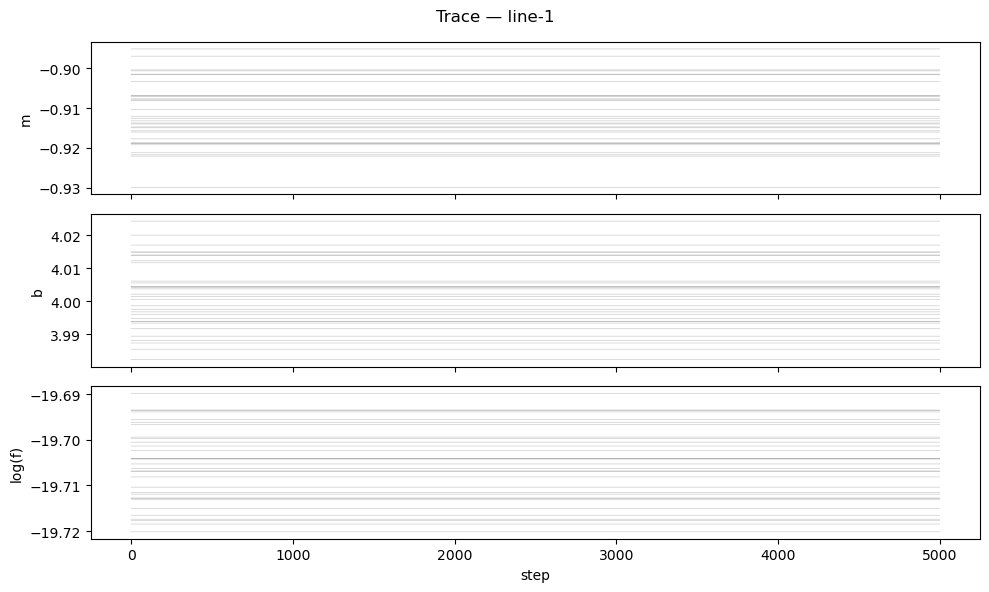

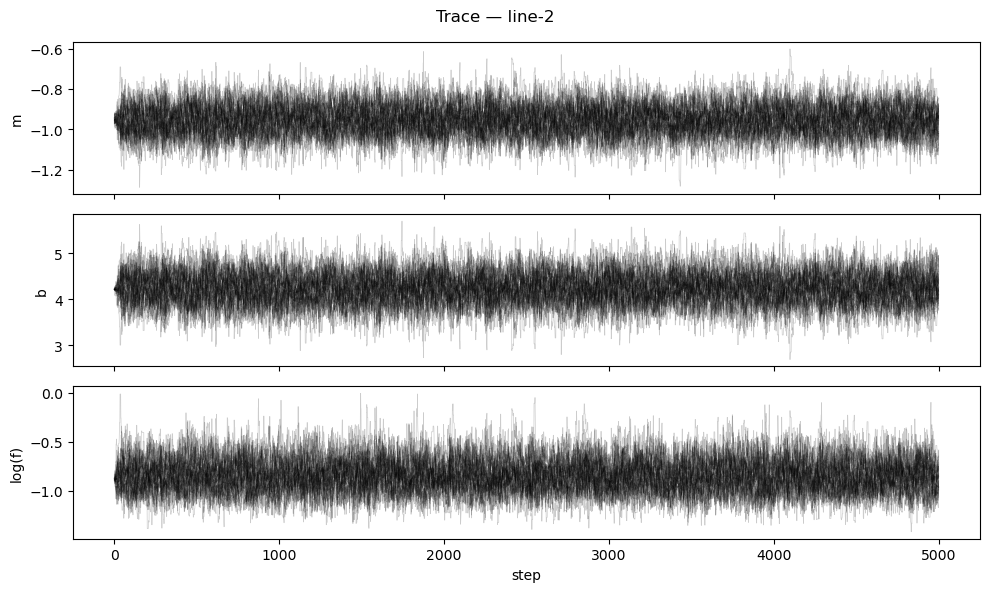

In [57]:
def plot_traces(sampler, title):
    samples = sampler.get_chain()
    fig, axes = plt.subplots(3, figsize=(10, 6), sharex=True)
    for i, (ax, lbl) in enumerate(zip(axes, LABELS)):
        ax.plot(samples[:, :, i], 'k', alpha=0.2, lw=0.5)
        ax.set_ylabel(lbl)
    axes[-1].set_xlabel('step')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_traces(sampler1, 'Trace — line-1')
plot_traces(sampler2, 'Trace — line-2')

## 7. Corner plots  (marginalized posteriors)

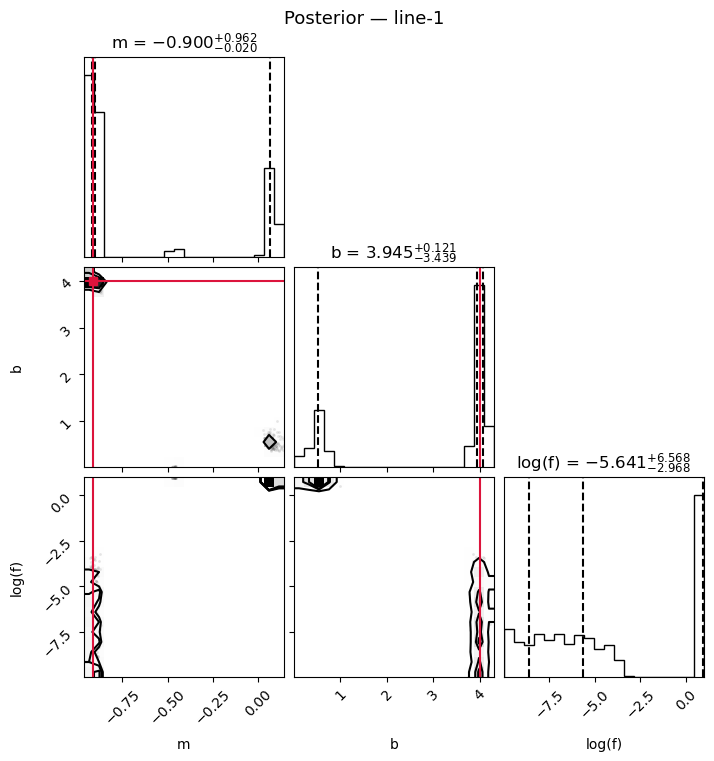

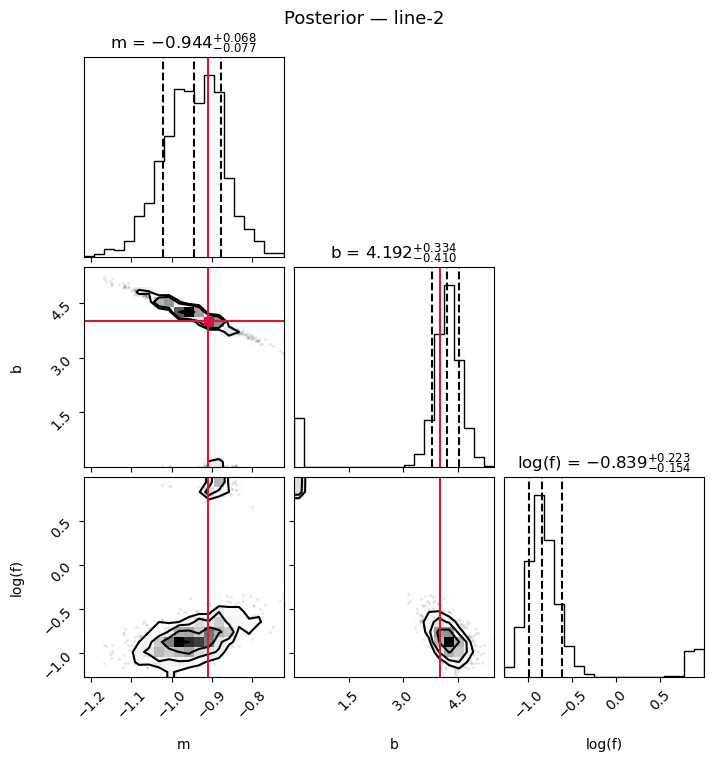

In [49]:
def plot_corner(flat, title):
    fig = corner.corner(flat, labels=LABELS,
                        truths=[TRUE_M, TRUE_B, None],
                        quantiles=[0.16, 0.5, 0.84],
                        show_titles=True, title_fmt='.3f',
                        truth_color='crimson')
    fig.suptitle(title, y=1.01, fontsize=13)
    plt.show()

plot_corner(flat1, 'Posterior — line-1')
plot_corner(flat2, 'Posterior — line-2')

## 8. Data + posterior predictive lines

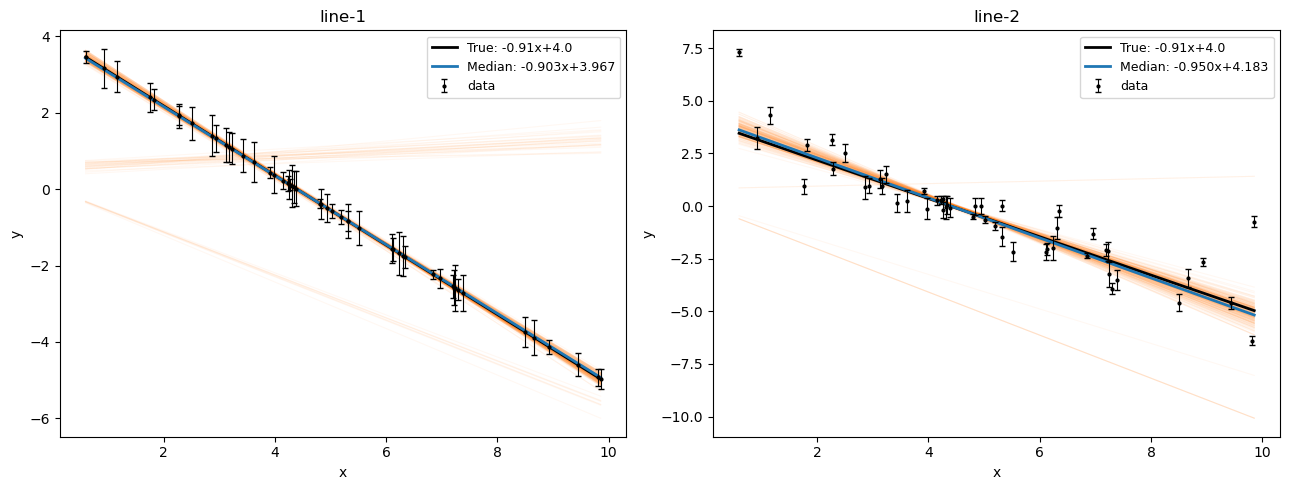

In [54]:
def plot_fit(ax, x, y, yerr, flat, title):
    x0 = np.linspace(x.min(), x.max(), 300)
    inds = np.random.randint(len(flat), size=200)
    for s in flat[inds]:
        ax.plot(x0, s[0]*x0 + s[1], color='C1', alpha=0.05, lw=0.8)
    ax.errorbar(x, y, yerr=yerr, fmt='.k', capsize=2, ms=4, elinewidth=0.8,
                label='data', zorder=5)
    ax.plot(x0, TRUE_M*x0 + TRUE_B, 'k', lw=2, label=f'True: {TRUE_M}x+{TRUE_B}')
    med = np.median(flat, axis=0)
    ax.plot(x0, med[0]*x0 + med[1], 'C0', lw=2,
            label=f'Median: {med[0]:.3f}x+{med[1]:.3f}')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(title); ax.legend(fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_fit(axes[0], x1, y1, e1, flat1, 'line-1')
plot_fit(axes[1], x2, y2, e2, flat2, 'line-2')
plt.tight_layout(); plt.show()

## 9. Parameter estimates  (16th, 50th, 84th percentiles)

In [13]:
def print_results(flat, label):
    print(f'\n{label}')
    print(f'  {"param":>8}  {"16%":>10}  {"50% (median)":>14}  {"84%":>10}  {"-σ":>8}  {"+σ":>8}')
    print('  ' + '-'*64)
    for i, lbl in enumerate(LABELS):
        p16, p50, p84 = np.percentile(flat[:, i], [16, 50, 84])
        print(f'  {lbl:>8}  {p16:>10.4f}  {p50:>14.4f}  {p84:>10.4f}  {p50-p16:>8.4f}  {p84-p50:>8.4f}')
    print(f'\n  True:  m={TRUE_M}  b={TRUE_B}  f=unknown')

print_results(flat1, 'line-1.dat')
print_results(flat2, 'line-2.dat')


line-1.dat
     param         16%    50% (median)         84%        -σ        +σ
  ----------------------------------------------------------------
         m     -0.9101         -0.9100     -0.9099    0.0001    0.0001
         b      3.9999          4.0000      4.0001    0.0001    0.0001
    log(f)    -19.7078        -19.7077    -19.7076    0.0001    0.0001

  True:  m=-0.91  b=4.0  f=unknown

line-2.dat
     param         16%    50% (median)         84%        -σ        +σ
  ----------------------------------------------------------------
         m     -1.0267         -0.9563     -0.8839    0.0704    0.0724
         b      3.9170          4.2427      4.5604    0.3257    0.3177
    log(f)     -1.0038         -0.8528     -0.6888    0.1510    0.1639

  True:  m=-0.91  b=4.0  f=unknown
